# Plant Disease — Proposed 1 Across Single Datasets

Evaluates the **Proposed 1** architecture (Custom Hybrid: Inception(Add) +
Skip+Concat + GlobalAveragePooling) trained independently on three domain-specific datasets:

| Dataset | Classes | Domain |
|---|---|---|
| **Wheat** | 3 | Brown Rust · Healthy · Yellow Rust |
| **Cotton** | 6 | Aphids · Army Worm · Bacterial Blight · Healthy · Powdery Mildew · Target Spot |
| **PlantVillage** | 15 | Potato (3) · Bell Pepper (2) · Tomato (10) |


In [1]:
!pip install matplotlib seaborn pandas numpy scikit-learn scipy -q
print('Ready.')


Ready.


In [2]:
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import seaborn as sns
from itertools import cycle
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 140, 'axes.spines.top': False, 'axes.spines.right': False,
    'font.family': 'DejaVu Sans', 'axes.titlesize': 13, 'axes.titleweight': 'bold',
    'axes.labelsize': 11, 'xtick.labelsize': 10, 'ytick.labelsize': 10,
    'legend.framealpha': 0.9, 'legend.fontsize': 9,
})
SAVE_DIR = '/kaggle/working/comparison_outputs'
os.makedirs(SAVE_DIR, exist_ok=True)
print('Imports ready. Outputs →', SAVE_DIR)


Imports ready. Outputs → /kaggle/working/comparison_outputs


In [3]:
import os

EXTRACT_ROOT = '/kaggle/input/datasets/jyotiradityachillal/singlelogs'
print("EXTRACT_ROOT =", EXTRACT_ROOT)

# ── Dataset registry — all three use the Proposed 1 architecture ──────────
DATASETS = [
    ('NB1_logs1', 'Wheat',        3,  '#1565C0',  # dark blue
     ['Wheat_Brown_rust','Wheat_Healthy','Wheat_Yellow_rust']),
    ('NB2_logs', 'Cotton',       6,  '#E65100',  # deep orange
     ['Cotton_Aphids','Cotton_Army_worm','Cotton_Bacterial_Blight',
      'Cotton_Healthy','Cotton_Powdery_mildew','Cotton_Target_Spot']),
    ('NB3_logs', 'PlantVillage', 15, '#2E7D32',  # dark green
     ['Potato_Early_blight','Potato_Late_blight','Potato_Healthy',
      'Bell_Pepper_Bacterial_spot','Bell_Pepper_Healthy',
      'Tomato_Bacterial_spot','Tomato_Early_blight','Tomato_Late_blight',
      'Tomato_Leaf_mold','Tomato_Septoria_leaf_spot','Tomato_Spider_mites',
      'Tomato_Target_spot','Tomato_Yellowleaf_curl_virus',
      'Tomato_Mosaic_virus','Tomato_Healthy']),
]

# Convenience
def fpath(folder, fname):
    return os.path.join(EXTRACT_ROOT, folder, fname)
def color(name):
    return next(c for f,n,nc,c,cls in DATASETS if n==name)

SAVE_DIR = '/kaggle/working/single_dataset_comparison'
import os; os.makedirs(SAVE_DIR, exist_ok=True)

print(f"Registry: {len(DATASETS)} datasets")
for fold,name,nc,clr,classes in DATASETS:
    ok='✓' if os.path.isdir(os.path.join(EXTRACT_ROOT,fold)) else '✗ MISSING'
    print(f"  [{ok}] {name:<16} {nc} classes")


EXTRACT_ROOT = /kaggle/input/datasets/jyotiradityachillal/singlelogs
Registry: 3 datasets
  [✓] Wheat            3 classes
  [✓] Cotton           6 classes
  [✓] PlantVillage     15 classes


## 1 · File Audit


In [4]:
EXPECTED = ['metrics_summary.csv','per_class_metrics.csv','roc_auc.csv',
            'training_history.csv','y_prob.npy','y_true.npy']
print(f"{'Dataset':<16} {'Req':>5}  {'Missing'}")
print("─"*50)
for fold,name,nc,clr,classes in DATASETS:
    d = os.path.join(EXTRACT_ROOT,fold)
    if not os.path.isdir(d): print(f"  {name:<14}  FOLDER MISSING"); continue
    present=set(os.listdir(d))
    miss=[f for f in EXPECTED if f not in present]
    print(f"  {name:<14}  {len(EXPECTED)-len(miss)}/{len(EXPECTED)}   {miss if miss else 'none'}")


Dataset            Req  Missing
──────────────────────────────────────────────────
  Wheat           6/6   none
  Cotton          6/6   none
  PlantVillage    6/6   none


## 2 · Metrics per Dataset


In [5]:
rows=[]
for fold,name,nc,clr,classes in DATASETS:
    p=fpath(fold,'metrics_summary.csv')
    if not os.path.exists(p): print(f"SKIP {name}"); continue
    df=pd.read_csv(p); r=df.iloc[0].to_dict()
    if 'sensitivity' in r and 'recall' not in r: r['recall']=r['sensitivity']
    r.update({'name':name,'nc':nc,'color':clr,'folder':fold,'classes':classes})
    rows.append(r)
metrics=pd.DataFrame(rows)

show=['name','nc','accuracy','precision','recall','f1','specificity','params','train_time_min','best_val_acc']
show=[c for c in show if c in metrics.columns]
fmt=metrics[show].copy()
for col in ['accuracy','precision','recall','f1','specificity','best_val_acc']:
    if col in fmt.columns: fmt[col]=fmt[col].map('{:.4f}'.format)
if 'params' in fmt.columns: fmt['params']=fmt['params'].apply(lambda x: f'{int(x):,}')
if 'train_time_min' in fmt.columns: fmt['train_time_min']=fmt['train_time_min'].map('{:.1f} min'.format)
fmt=fmt.rename(columns={'name':'Dataset','nc':'Classes','train_time_min':'Train Time','best_val_acc':'Best Val Acc'})
print("=== Proposed 1 — Per-Dataset Results ===")
print(fmt.to_string(index=False))
metrics.to_csv(os.path.join(SAVE_DIR,'metrics_per_dataset.csv'),index=False)


=== Proposed 1 — Per-Dataset Results ===
     Dataset  Classes accuracy precision recall     f1 specificity     params Train Time Best Val Acc
       Wheat        3   0.9502    0.9511 0.9502 0.9499      0.9755 59,775,267    9.9 min       0.9683
      Cotton        6   0.5355    0.5301 0.5355 0.5166      0.9071 59,775,462   15.7 min       0.5529
PlantVillage       15   0.9767    0.9768 0.9767 0.9768      0.9983 59,776,047   56.1 min       0.9780


## 3 · Accuracy, F1, Precision, Recall per Dataset


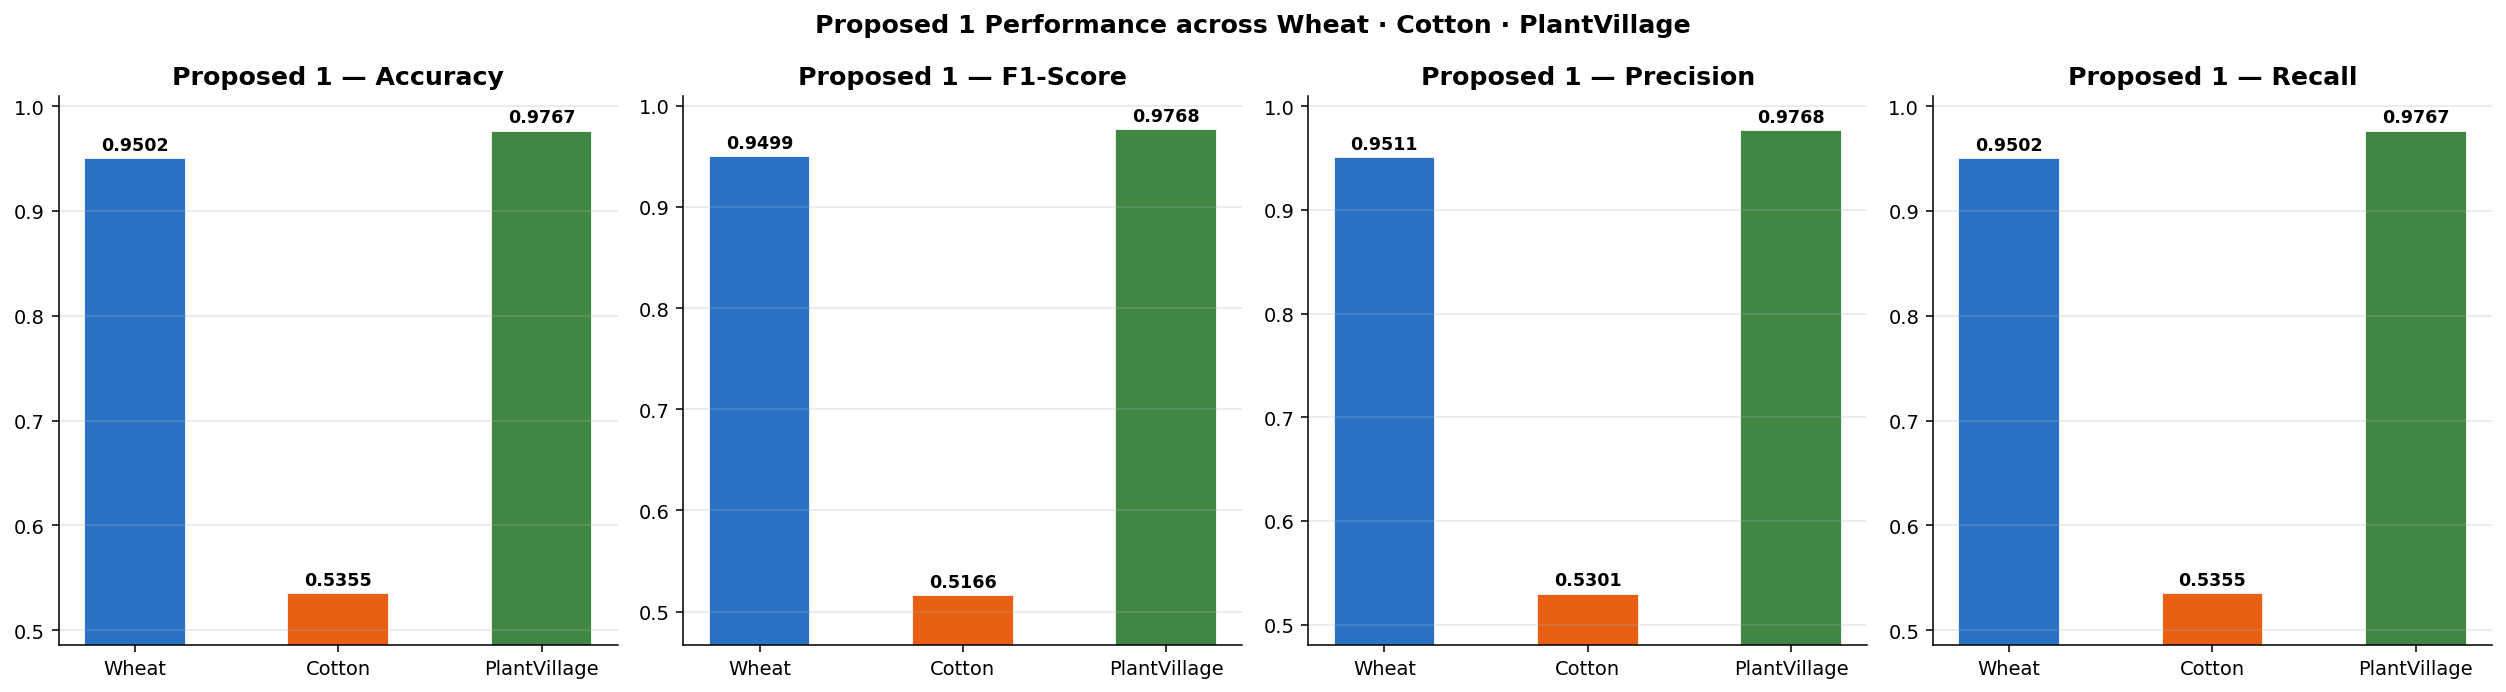

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for ax, col, title in [
    (axes[0],'accuracy',   'Accuracy'),
    (axes[1],'f1',         'F1-Score'),
    (axes[2],'precision',  'Precision'),
    (axes[3],'recall',     'Recall'),
]:
    if col not in metrics.columns: ax.set_visible(False); continue
    clrs=[r['color'] for _,r in metrics.iterrows()]
    bars=ax.bar(metrics['name'],metrics[col],color=clrs,edgecolor='white',width=0.5,alpha=0.92)
    for bar,v in zip(bars,metrics[col]):
        ax.text(bar.get_x()+bar.get_width()/2,bar.get_height()+0.004,
                f'{v:.4f}',ha='center',va='bottom',fontsize=9,fontweight='bold')
    ax.set_ylim(max(0.4,metrics[col].min()-0.05), 1.01)
    ax.set_title(f'Proposed 1 — {title}',fontweight='bold')
    ax.grid(True,axis='y',alpha=0.3)

plt.suptitle('Proposed 1 Performance across Wheat · Cotton · PlantVillage',
             fontsize=13,fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR,'metrics_per_dataset.png'),dpi=140,bbox_inches='tight')
plt.show()


## 4 · ROC Curves — Per Dataset


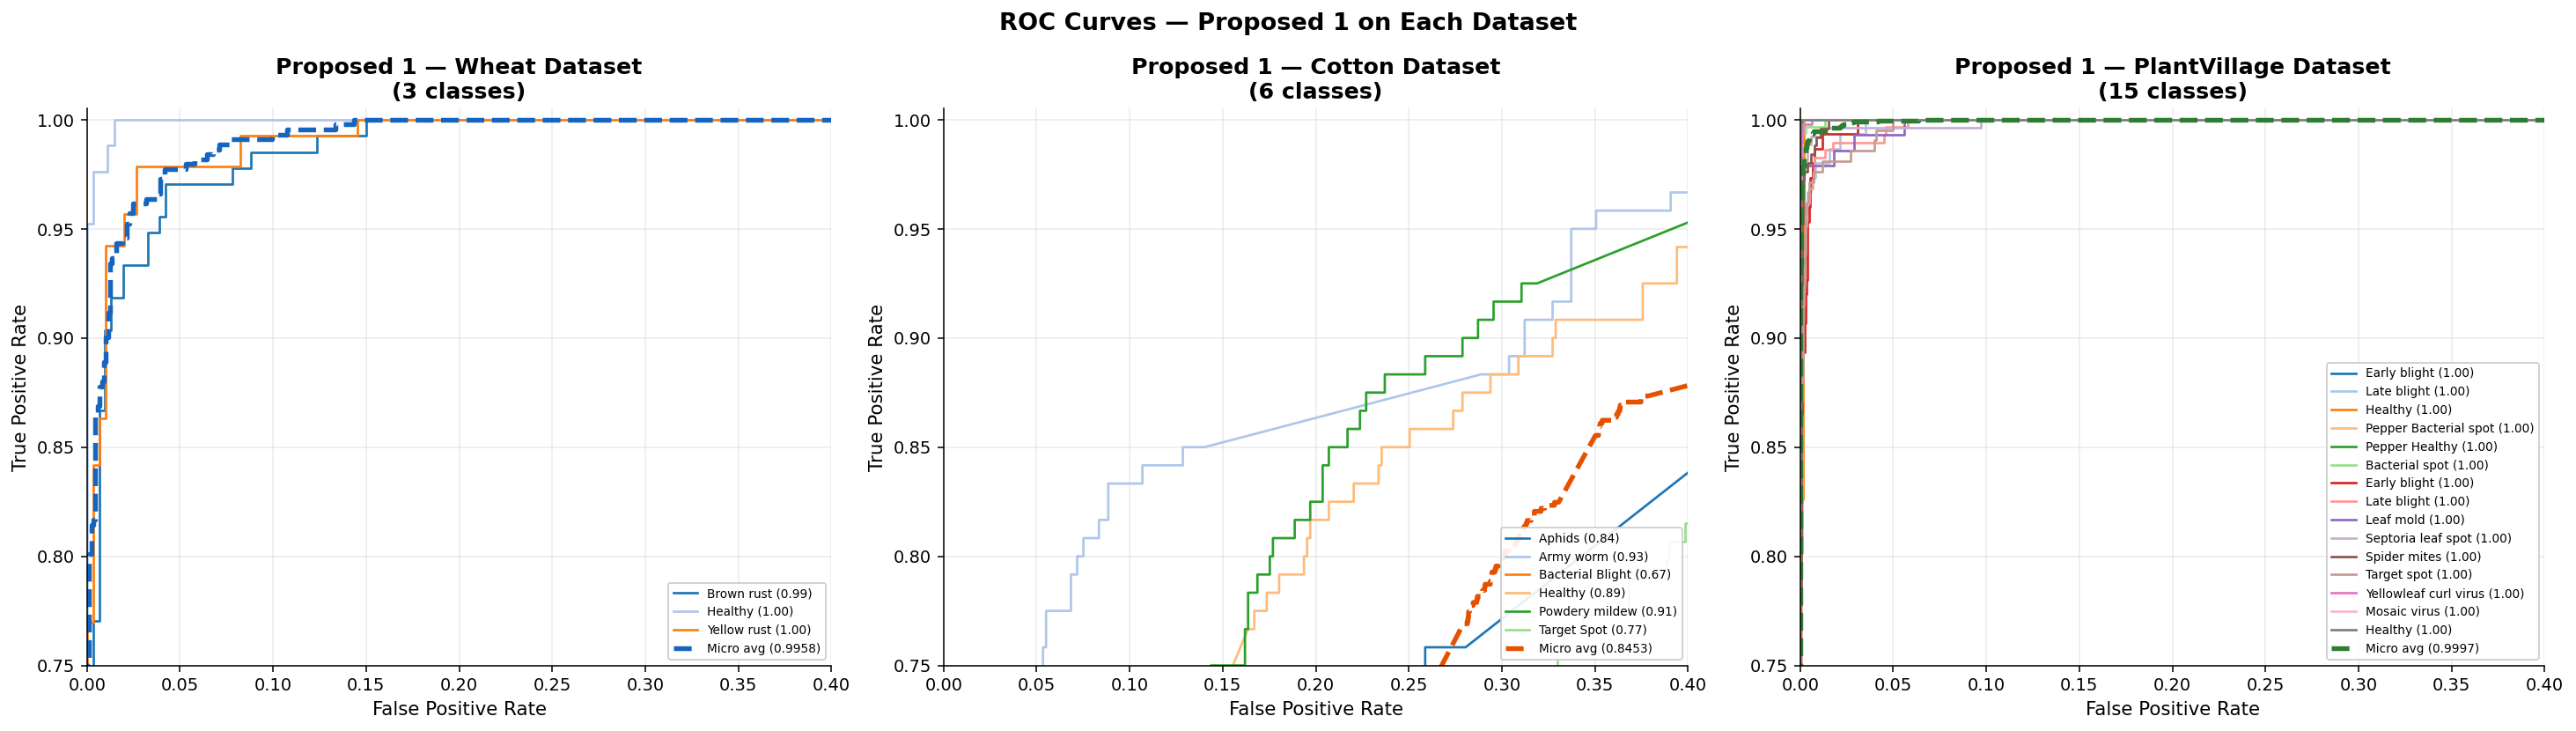

In [7]:
fig, axes = plt.subplots(1, len(DATASETS), figsize=(7*len(DATASETS), 6))
if len(DATASETS)==1: axes=[axes]

for ax,(fold,name,nc,clr,classes) in zip(axes,DATASETS):
    prob_p=fpath(fold,'y_prob.npy'); true_p=fpath(fold,'y_true.npy')
    if not (os.path.exists(prob_p) and os.path.exists(true_p)):
        ax.set_title(f'{name} — data missing'); continue
    y_prob=np.load(prob_p); y_true=np.load(true_p)
    n_cls=y_prob.shape[1]
    y_bin=label_binarize(y_true,classes=list(range(n_cls)))
    clrs_c=cycle(plt.cm.tab20.colors)
    for i,cc in zip(range(n_cls),clrs_c):
        fi,ti,_=roc_curve(y_bin[:,i],y_prob[:,i]); a=auc(fi,ti)
        lbl=classes[i].split('_',1)[-1].replace('_',' ') if i<len(classes) else str(i)
        ax.plot(fi,ti,color=cc,lw=1.4,label=f'{lbl} ({a:.2f})')
    fpr_m,tpr_m,_=roc_curve(y_bin.ravel(),y_prob.ravel()); ma=auc(fpr_m,tpr_m)
    ax.plot(fpr_m,tpr_m,color=clr,lw=2.8,ls='--',label=f'Micro avg ({ma:.4f})')
    ax.plot([0,1],[0,1],'k--',lw=0.8,alpha=0.4)
    ax.set_xlim([0,0.4]); ax.set_ylim([0.75,1.005])
    ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
    ax.set_title(f'Proposed 1 — {name} Dataset\n({nc} classes)',fontweight='bold')
    ax.legend(loc='lower right',fontsize=7)
    ax.grid(alpha=0.25)

plt.suptitle('ROC Curves — Proposed 1 on Each Dataset',fontsize=14,fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR,'roc_per_dataset.png'),dpi=140,bbox_inches='tight')
plt.show()


## 5 · Training Convergence


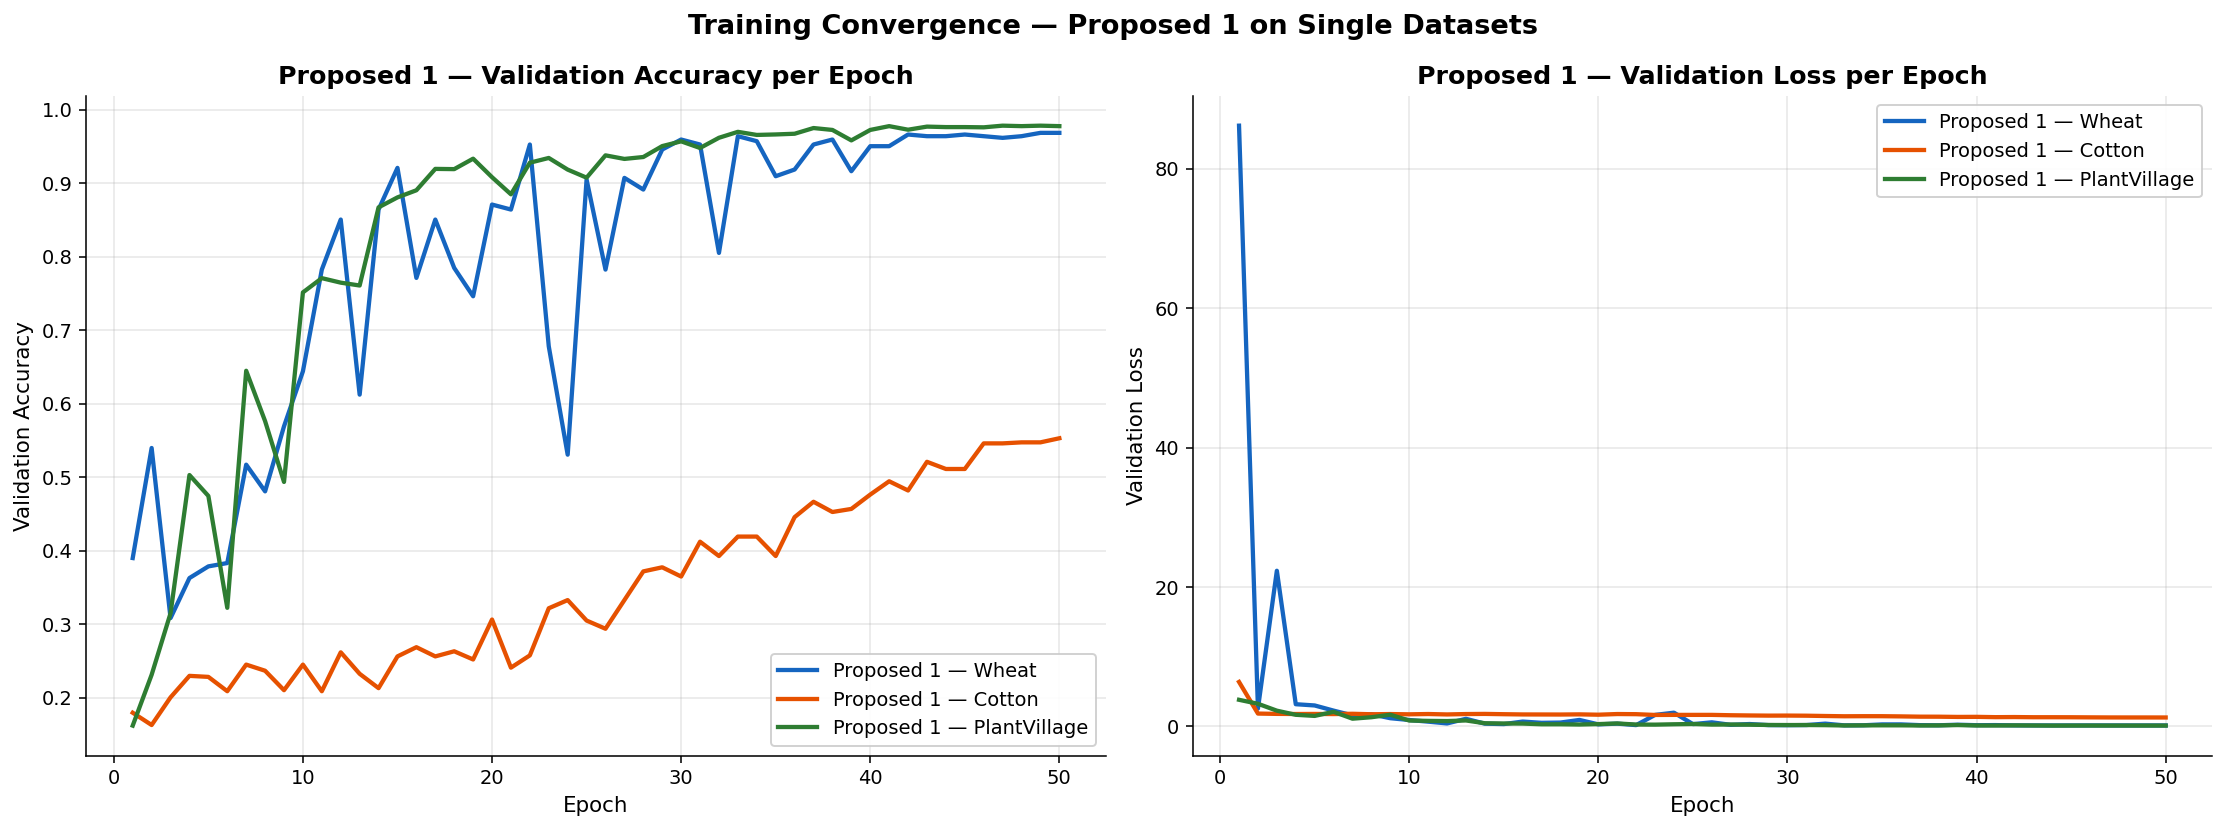

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for fold,name,nc,clr,classes in DATASETS:
    hp=fpath(fold,'training_history.csv')
    if not os.path.exists(hp): continue
    df=pd.read_csv(hp)
    ep=df['epoch'] if 'epoch' in df.columns else range(1,len(df)+1)
    if 'val_accuracy' in df.columns:
        axes[0].plot(ep,df['val_accuracy'],color=clr,lw=2.2,label=f'Proposed 1 — {name}')
    if 'val_loss' in df.columns:
        axes[1].plot(ep,df['val_loss'],color=clr,lw=2.2,label=f'Proposed 1 — {name}')

for ax,ylabel,title in [
    (axes[0],'Validation Accuracy','Proposed 1 — Validation Accuracy per Epoch'),
    (axes[1],'Validation Loss',    'Proposed 1 — Validation Loss per Epoch'),
]:
    ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel)
    ax.set_title(title,fontweight='bold'); ax.legend(fontsize=10); ax.grid(alpha=0.3)

plt.suptitle('Training Convergence — Proposed 1 on Single Datasets',fontsize=14,fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR,'convergence_single.png'),dpi=140,bbox_inches='tight')
plt.show()


## 6 · Per-Class F1-Score — Each Dataset


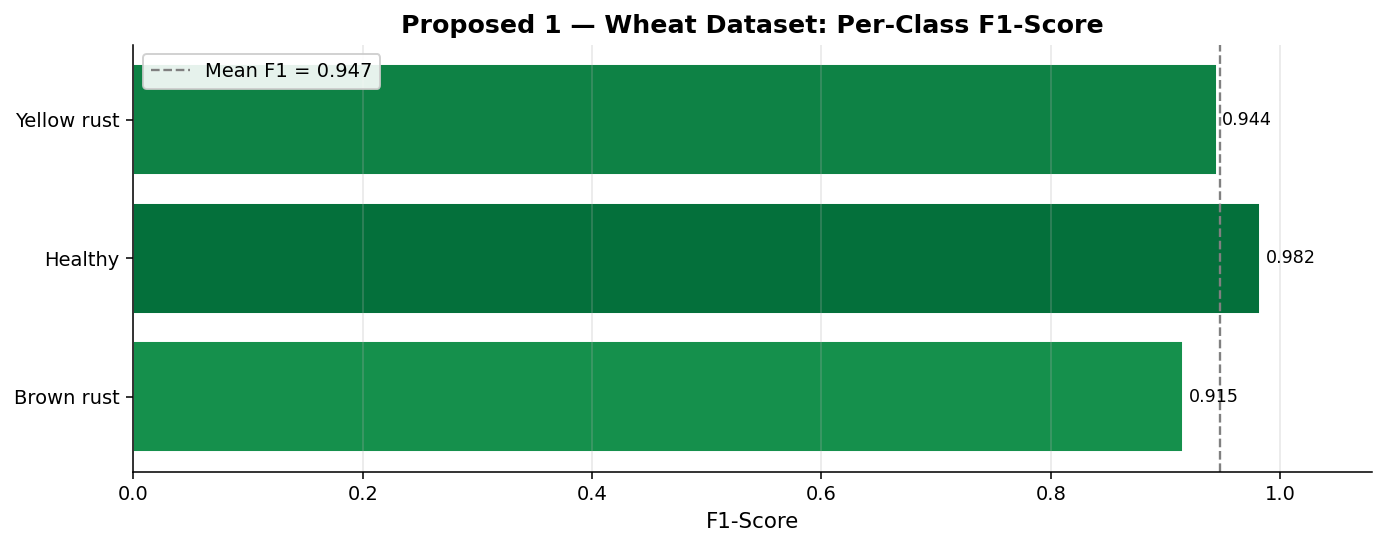


Wheat (3 classes):
      Class Sensitivity Precision     F1 Specificity
 Brown rust      0.8815    0.9520 0.9154      0.9805
    Healthy      0.9821    0.9821 0.9821      0.9891
Yellow rust      0.9784    0.9128 0.9444      0.9571


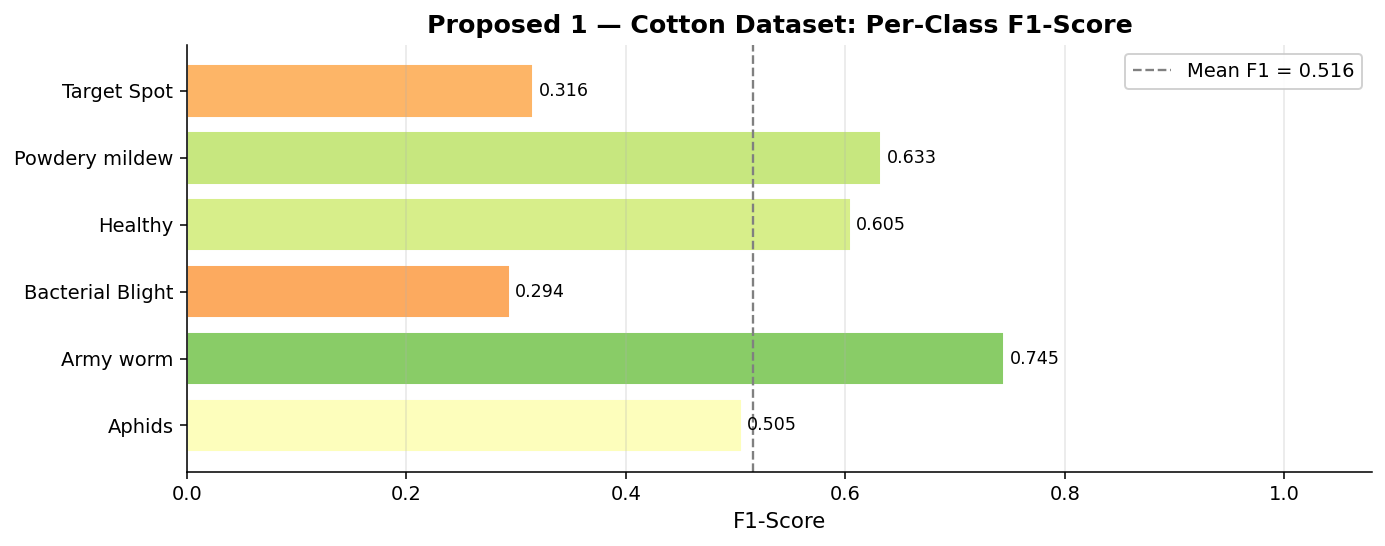


Cotton (6 classes):
           Class Sensitivity Precision     F1 Specificity
          Aphids      0.5833    0.4459 0.5054      0.8548
       Army worm      0.7417    0.7479 0.7448      0.9499
Bacterial Blight      0.2500    0.3571 0.2941      0.9098
         Healthy      0.7333    0.5146 0.6048      0.8614
  Powdery mildew      0.6750    0.5956 0.6328      0.9082
     Target Spot      0.2269    0.5192 0.3158      0.9583


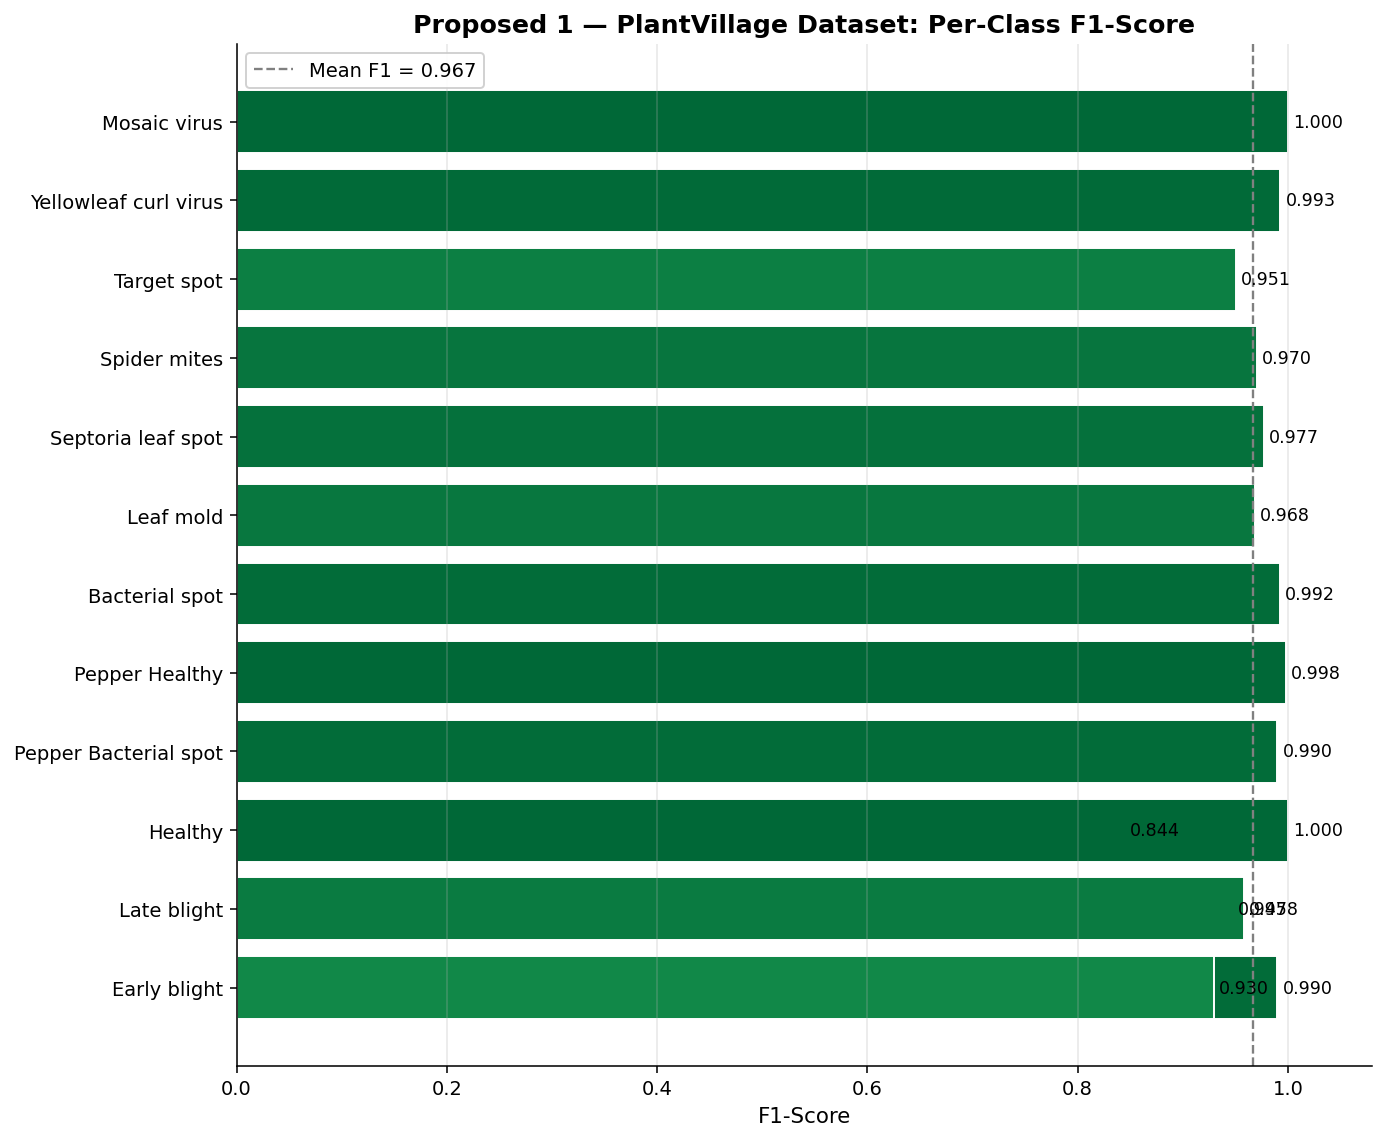


PlantVillage (15 classes):
                Class Sensitivity Precision     F1 Specificity
         Early blight      0.9933    0.9868 0.9900      0.9993
          Late blight      0.9533    0.9408 0.9470      0.9969
              Healthy      0.8261    0.8636 0.8444      0.9990
Pepper Bacterial spot      0.9866    0.9932 0.9899      0.9997
       Pepper Healthy      0.9955    1.0000 0.9977      1.0000
       Bacterial spot      0.9875    0.9968 0.9921      0.9996
         Early blight      0.9267    0.9329 0.9298      0.9966
          Late blight      0.9582    0.9582 0.9582      0.9957
            Leaf mold      0.9650    0.9718 0.9684      0.9986
   Septoria leaf spot      0.9737    0.9811 0.9774      0.9982
         Spider mites      0.9762    0.9647 0.9704      0.9968
          Target spot      0.9619    0.9395 0.9506      0.9955
Yellowleaf curl virus      0.9917    0.9938 0.9927      0.9989
         Mosaic virus      1.0000    1.0000 1.0000      1.0000
              Healthy      

In [9]:
for fold,name,nc,clr,classes in DATASETS:
    fp=fpath(fold,'per_class_metrics.csv')
    if not os.path.exists(fp): continue
    df=pd.read_csv(fp)
    df['short']=df['class'].str.split('_',n=1).str[1].str.replace('_',' ')

    fig,ax=plt.subplots(figsize=(10,max(4,nc*0.55)))
    bars=ax.barh(df['short'],df['f1'],
                 color=[plt.cm.RdYlGn(v) for v in df['f1']],edgecolor='white')
    for bar,v in zip(bars,df['f1']):
        ax.text(bar.get_width()+0.005,bar.get_y()+bar.get_height()/2,
                f'{v:.3f}',va='center',fontsize=9)
    ax.set_xlim(0,1.08)
    ax.axvline(df['f1'].mean(),color='gray',ls='--',lw=1.2,
               label=f'Mean F1 = {df["f1"].mean():.3f}')
    ax.set_title(f'Proposed 1 — {name} Dataset: Per-Class F1-Score',fontweight='bold',fontsize=13)
    ax.set_xlabel('F1-Score'); ax.legend(fontsize=10); ax.grid(True,axis='x',alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR,f'per_class_{name}.png'),dpi=140,bbox_inches='tight')
    plt.show()

    print(f"\n{name} ({nc} classes):")
    pc=df[['short','sensitivity','precision','f1','specificity']].copy()
    pc.columns=['Class','Sensitivity','Precision','F1','Specificity']
    for col in ['Sensitivity','Precision','F1','Specificity']:
        pc[col]=pc[col].map('{:.4f}'.format)
    print(pc.to_string(index=False))


## 7 · Sensitivity & Specificity — Dataset Overview


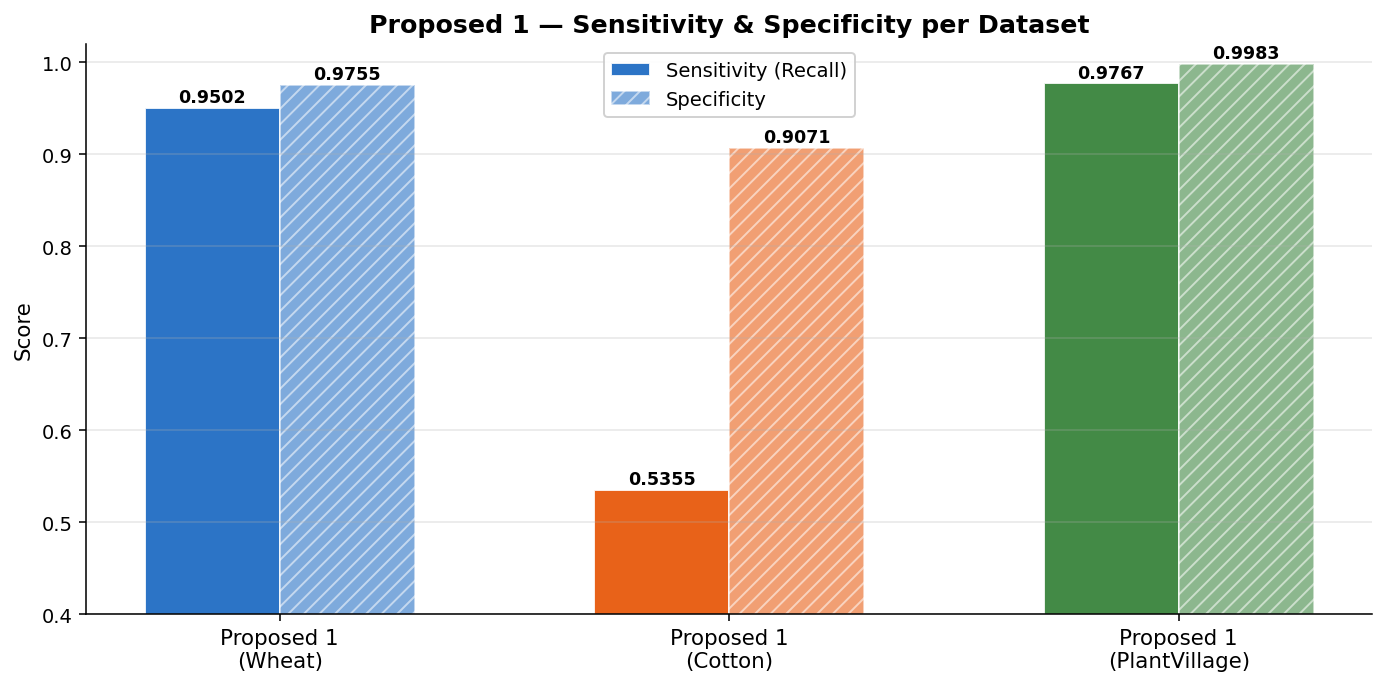

In [10]:
fig,ax=plt.subplots(figsize=(10,5))
x=np.arange(len(DATASETS)); w=0.3
names=[name for _,name,*_ in DATASETS]
clrs_=[clr for _,_,_,clr,_ in DATASETS]
sens_=[metrics[metrics['name']==n]['recall'].values[0] if n in metrics['name'].values else 0 for n in names]
spec_=[metrics[metrics['name']==n]['specificity'].values[0] if n in metrics['name'].values else 0 for n in names]
b1=ax.bar(x-w/2,sens_,w,color=clrs_,alpha=0.9,label='Sensitivity (Recall)',edgecolor='white')
b2=ax.bar(x+w/2,spec_,w,color=clrs_,alpha=0.55,hatch='///',label='Specificity',edgecolor='white')
for bars in [b1,b2]:
    for bar in bars:
        ax.text(bar.get_x()+bar.get_width()/2,bar.get_height()+0.002,
                f'{bar.get_height():.4f}',ha='center',va='bottom',fontsize=9,fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels([f'Proposed 1\n({n})' for n in names],fontsize=11)
ax.set_ylim(0.4,1.02); ax.set_ylabel('Score')
ax.set_title('Proposed 1 — Sensitivity & Specificity per Dataset',fontweight='bold',fontsize=13)
ax.legend(fontsize=10); ax.grid(True,axis='y',alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR,'sensitivity_specificity.png'),dpi=140,bbox_inches='tight')
plt.show()


In [11]:
print("=== Output files ===")
for f in sorted(os.listdir(SAVE_DIR)):
    print(f"  {f}  ({os.path.getsize(os.path.join(SAVE_DIR,f))//1024} KB)")
import shutil
shutil.make_archive('/kaggle/working/single_dataset_comparison','zip',SAVE_DIR)
print("\nZip → /kaggle/working/single_dataset_comparison.zip")


=== Output files ===
  convergence_single.png  (175 KB)
  metrics_per_dataset.csv  (1 KB)
  metrics_per_dataset.png  (59 KB)
  per_class_Cotton.png  (46 KB)
  per_class_PlantVillage.png  (85 KB)
  per_class_Wheat.png  (35 KB)
  roc_per_dataset.png  (172 KB)
  sensitivity_specificity.png  (71 KB)

Zip → /kaggle/working/single_dataset_comparison.zip
